# Deconvolve the origins of replication

June 25, 2024

## Goal:
Deconvolve the origins of replication and show 1-2 great examples.

Procedure:
1. Load the chromatin deconvolution model.
2. Add a function to load the mnase and bins for the origin of replication

Note:
- We don't have the copy number correction scaling factor yet, it should not have a big effect on the chromatin, but something to keep in mind and place on the to do list.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [1]:
from src.config import load_combined_gene_expression_by_config_type,\
    load_configs_by_config_type

config_type = 'shared'

chrom_config1, chrom_config2 = load_configs_by_config_type(config_type,
    with_copy_correction=True)


In [157]:
from src.combined_chromatin_model import CombinedChromatinModel

combined_model = CombinedChromatinModel(chrom_config1, chrom_config2)


In [158]:
combined_model.load_combined_mnase_orc('ARS1623')

Applying a normalization for length distribution
Applying a normalization for length distribution


In [161]:
combined_model.setup_deconv_model()

In [163]:
combined_model.deconvolve()

Deconvolving combined model with gamma=0.006
Deconvolving bin size: 24x24
of G shape: (31, 830)
Deconvolving with gamma=0.006
0/830 - 00:00:00.126
100/830 - 00:00:11.544
200/830 - 00:00:22.053
300/830 - 00:00:32.526
400/830 - 00:00:43.108
500/830 - 00:00:53.902
600/830 - 00:01:04.875
700/830 - 00:01:15.799
800/830 - 00:01:26.998
Deconvolved in : 00:01:31.348
The fitting norm is 14.48, the smoothing norm is: 30.63


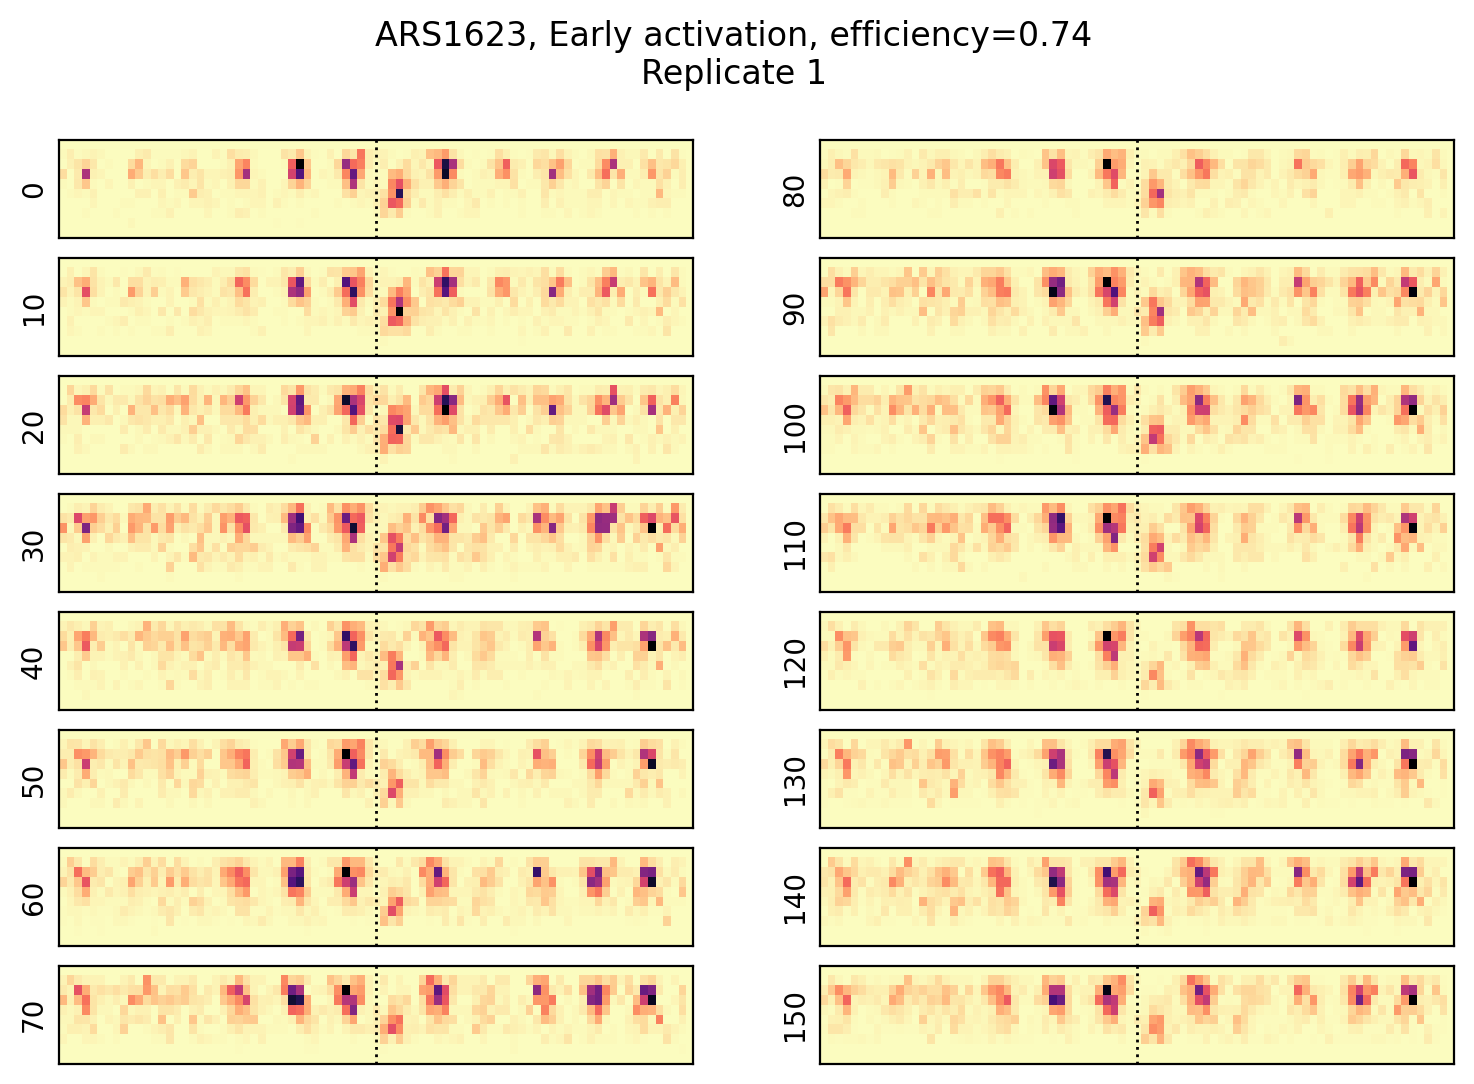

In [1513]:
fig = combined_model.plot_raw_origin_data(1)

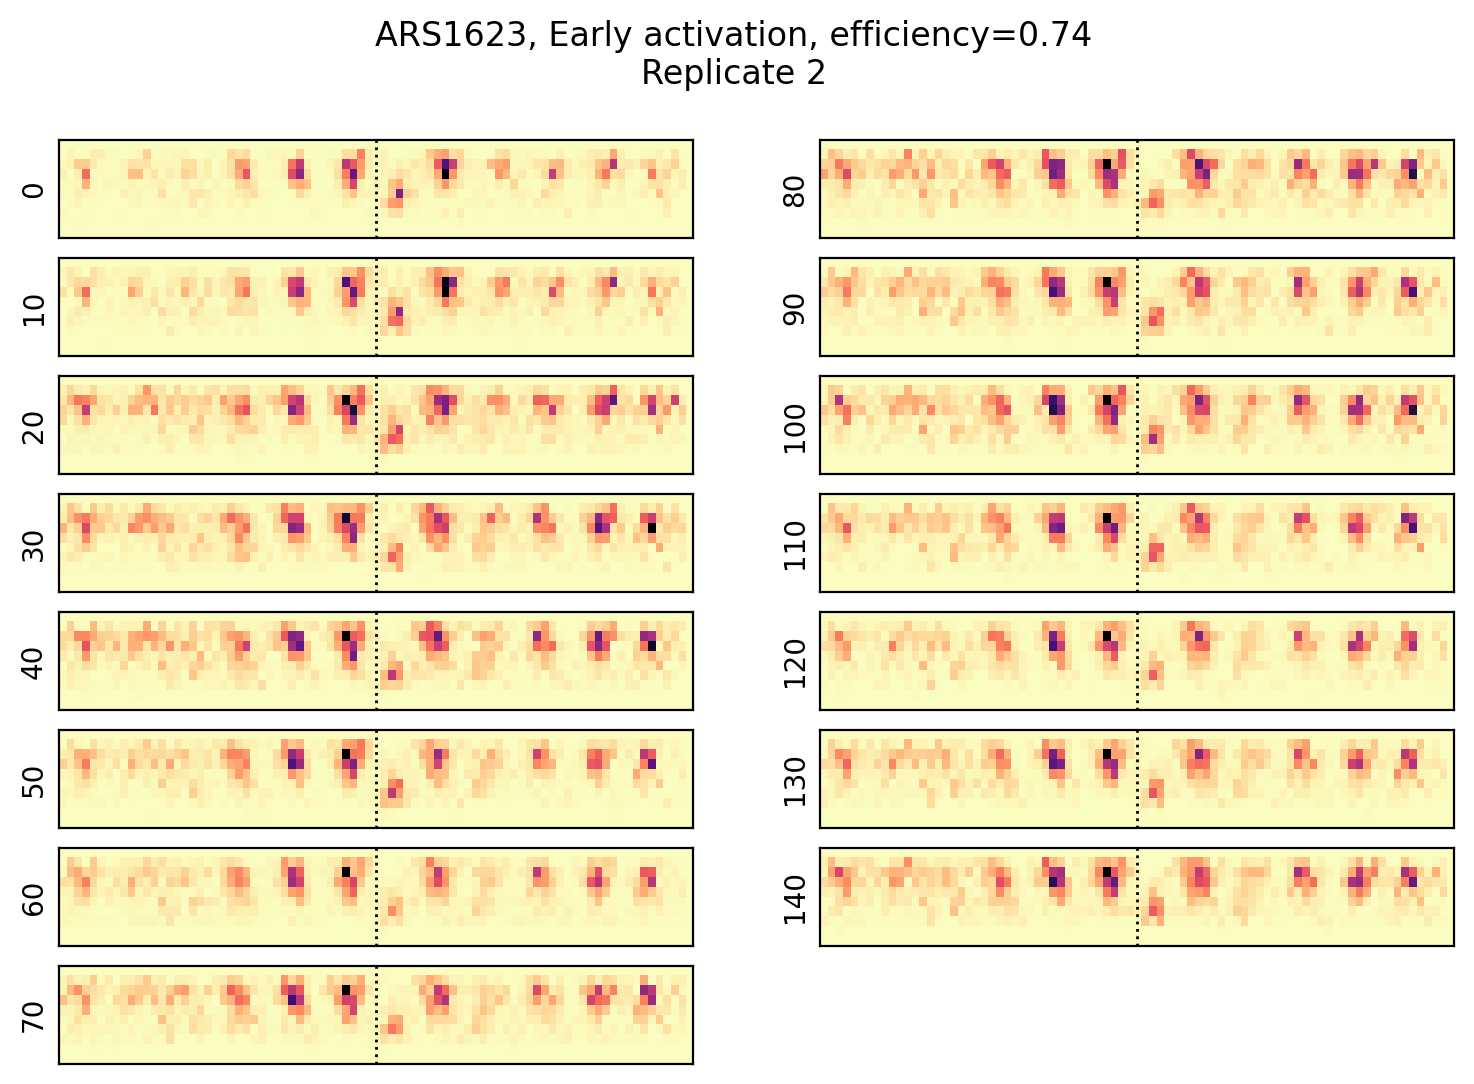

In [1514]:
fig = combined_model.plot_raw_origin_data(2)

In [1515]:
combined_model.find_origin_p1_and_m1_nucleosome_position()

Nucleosomal fragment length range:  (144, 192)
Origin fragment length range:  (24, 120)
The +1 span for tracking is: (633926, 634286)  length:  360
The -1 span for tracking is: (633566, 633926)  length:  360
The span for origin occupancy is: (633782, 634070)  length:  288
Nucleosomal fragment length range:  (144, 192)
Origin fragment length range:  (24, 120)
The +1 span for tracking is: (633926, 634286)  length:  360
The -1 span for tracking is: (633566, 633926)  length:  360
The span for origin occupancy is: (633782, 634070)  length:  288


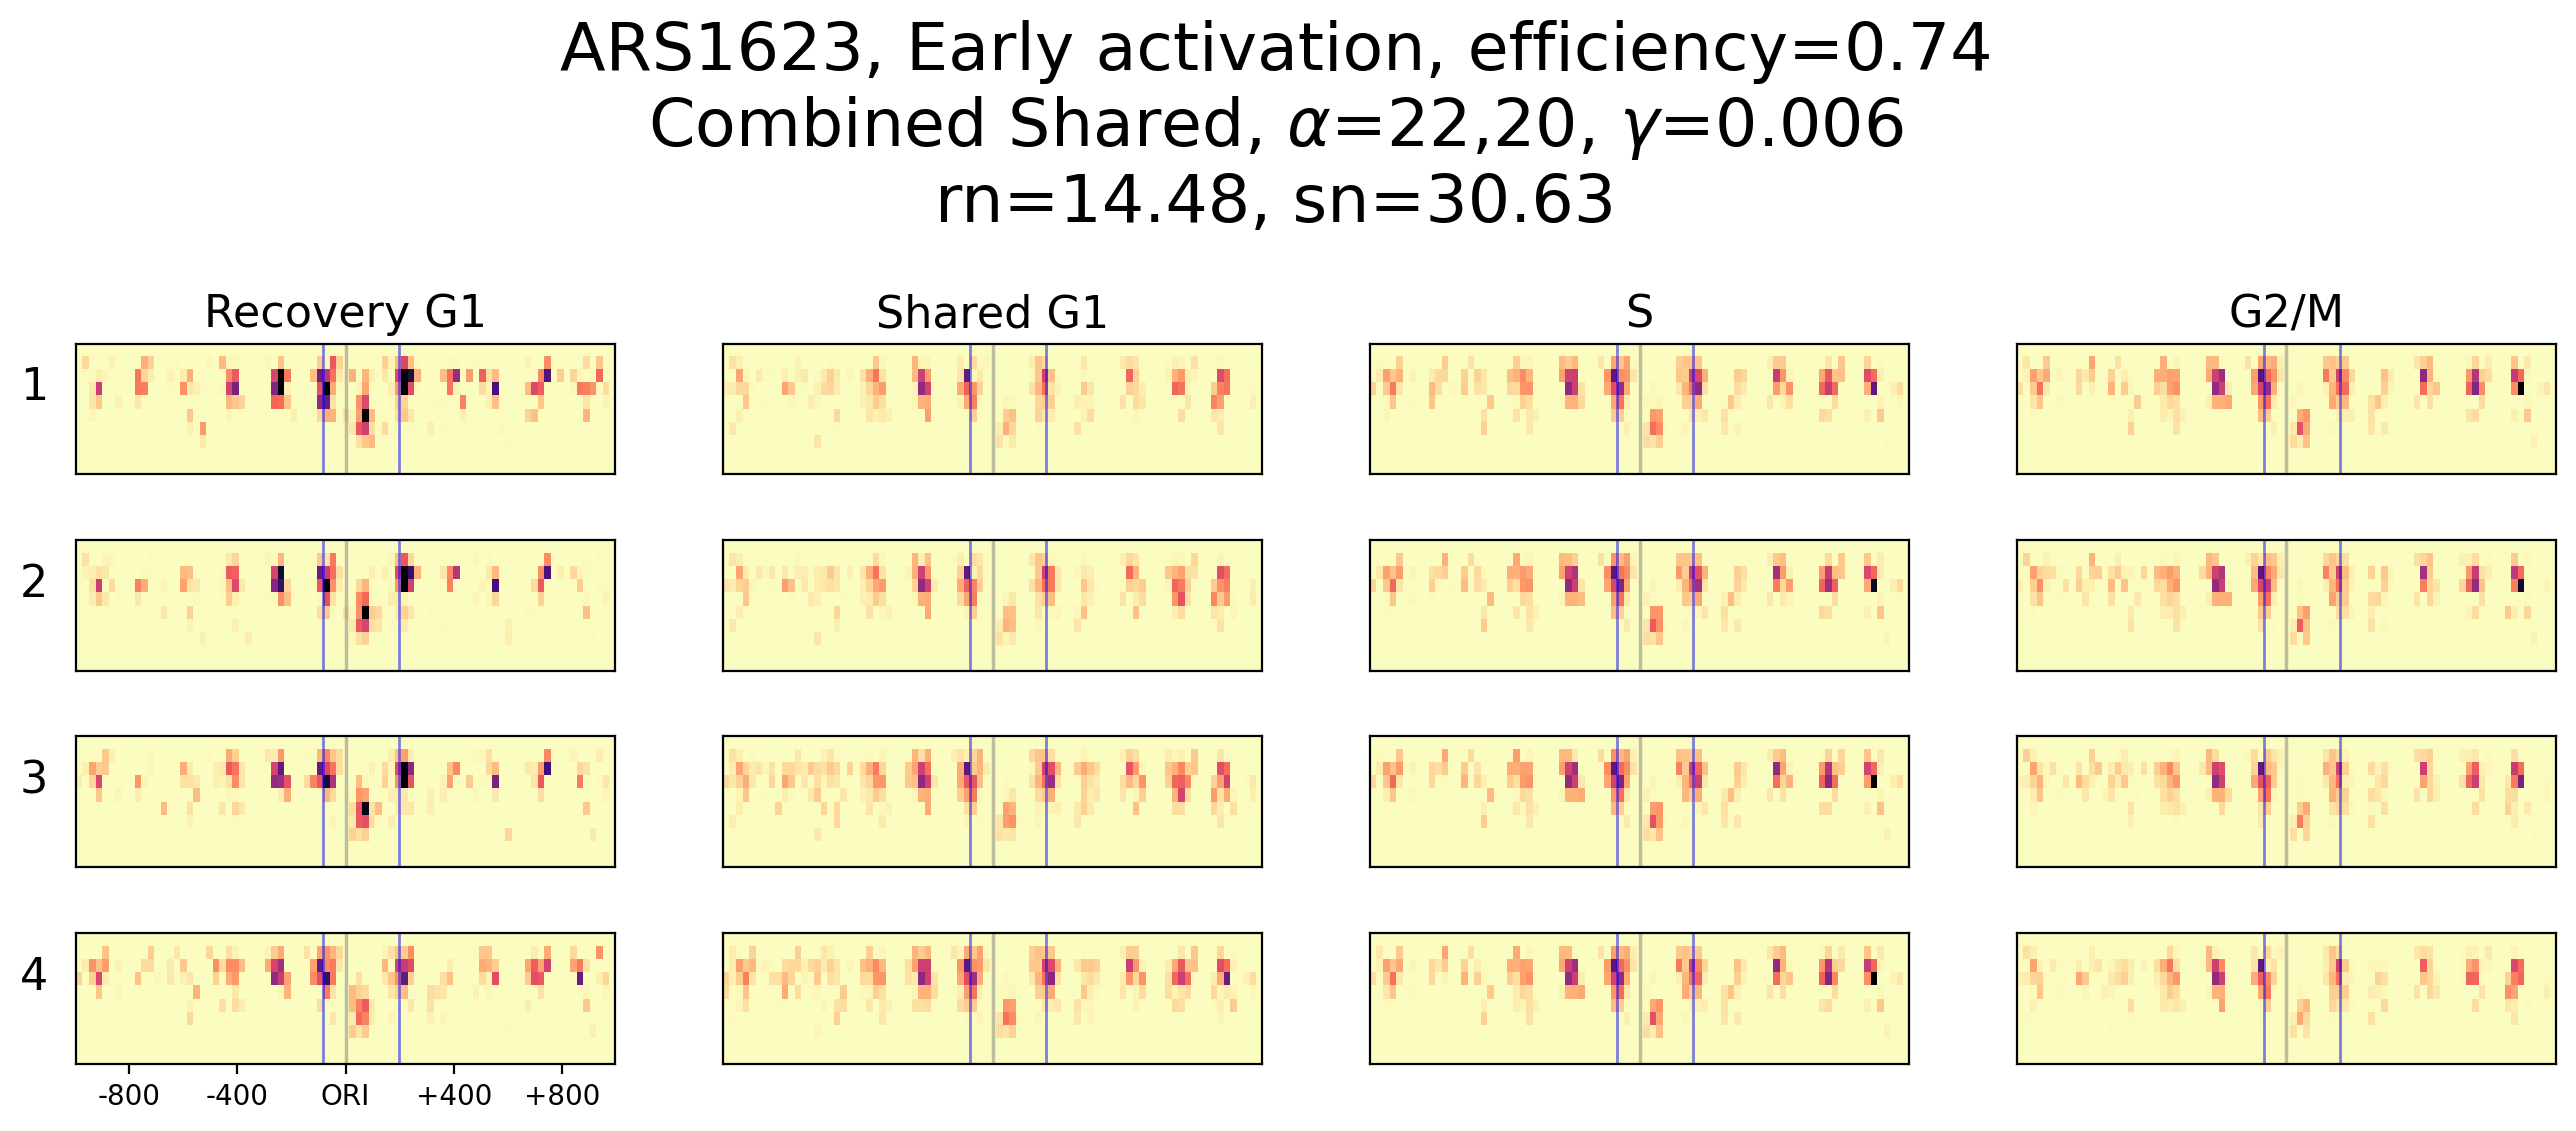

In [1516]:
fig = combined_model.create_deconvolution_plots_abbreviated_flipped(vmax=75)

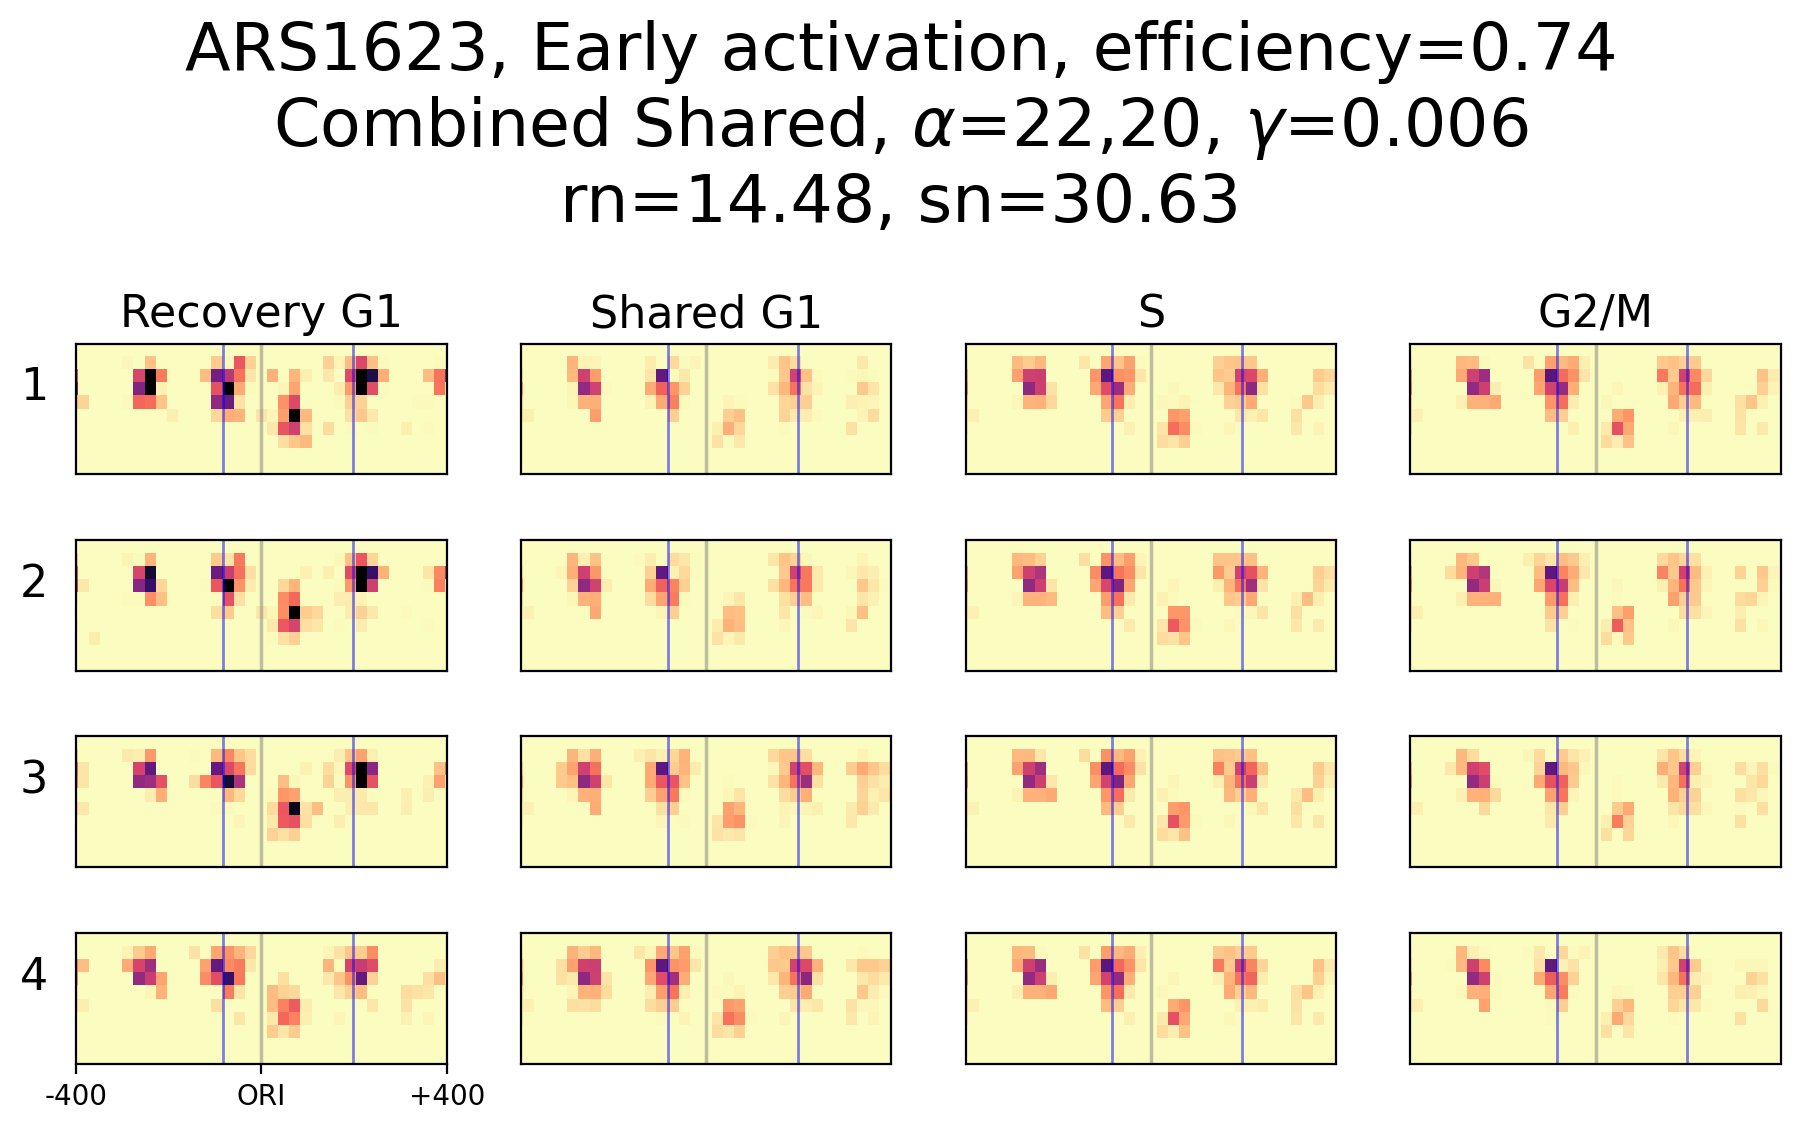

In [1517]:
fig = combined_model.create_deconvolution_plots_abbreviated_flipped(zoom=800, vmax=75,
                                                                   num_rows=4)

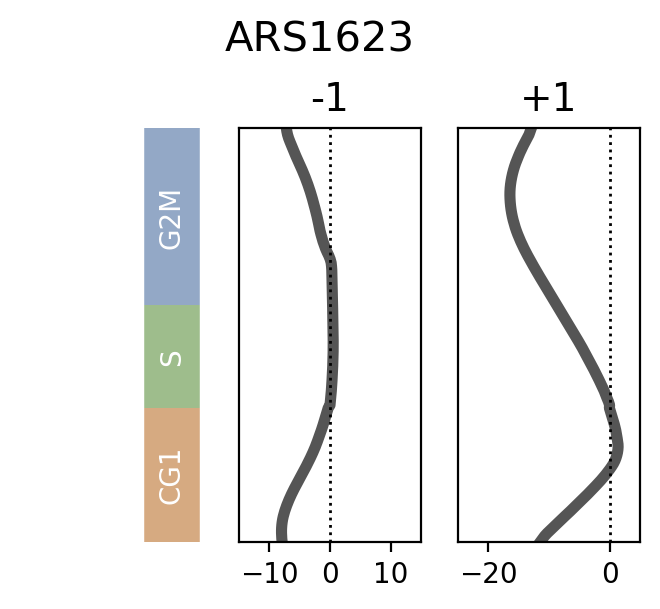

In [1522]:
fig = combined_model.chrom1_model.plot_nucleosome_shift()

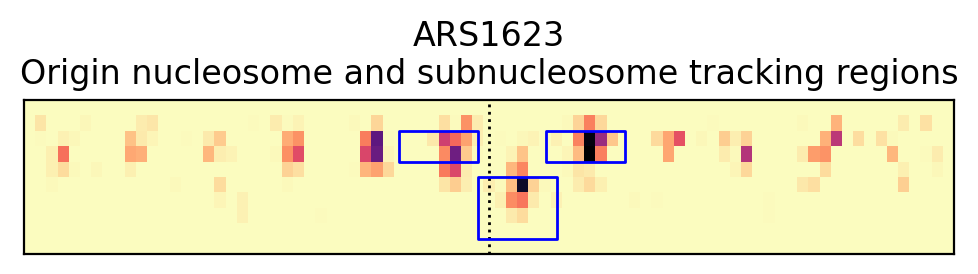

In [1521]:
fig = combined_model.chrom1_model.plot_origin_trackers()

todo: resolve the timepoints plotted to be the average of rep1 and rep2


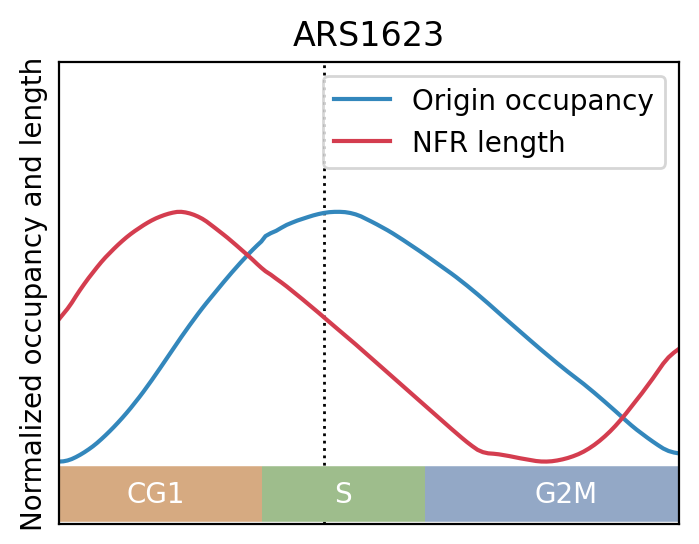

In [1523]:
fig = combined_model.plot_nfr_origin_occ()

In [1545]:
from src.utils import mkdir_safe

outdir = 'output/deconvolve_origins_2024_06_28/'
mkdir_safe(outdir)


Creating directory: output/deconvolve_origins_2024_06_28/...Directory exists. Skipping.


In [1546]:
combined_model.save_origin_plots(outdir, 1)

todo: resolve the timepoints plotted to be the average of rep1 and rep2


In [1547]:
combined_model.save_deconvolved_origin_outputs(outdir, 0)

Saved to output/deconvolve_origins_2024_06_28//0_f_oridb_809_ARS1623.npy...
Saved to output/deconvolve_origins_2024_06_28//0_tracking_oridb_809_ARS1623.csv...
Saved to output/deconvolve_origins_2024_06_28//0_meta_oridb_809_ARS1623.csv...


In [ ]:
!python src/deconvolve_origins_runner.py output/deconvolve_origins_2024_06_28/ 0.0066 shared 10

System arguments:	('src/deconvolve_origins_runner.py', 'output/deconvolve_origins_2024_06_28/', '0.0066', 'shared', '10')
Config type:  shared
Index: [10/798] Deconvolving combined model, origin: ARS107.5/oridb_11...
Output to: output/deconvolve_origins_2024_06_28/
Creating directory: output/deconvolve_origins_2024_06_28//chromatin...
Creating directory: output/deconvolve_origins_2024_06_28//plots...
Applying a normalization for length distribution
Applying a normalization for length distribution
Deconvolving combined model with gamma=0.0066
Deconvolving bin size: 24x24
of G shape: (31, 830)
Deconvolving with gamma=0.0066
0/830 - 00:00:00.174
100/830 - 00:00:11.872
200/830 - 00:00:23.354
300/830 - 00:00:34.806
400/830 - 00:00:46.044
500/830 - 00:00:57.323
